In [1]:
import sys
from pathlib import Path

# add src directory to python path
sys.path.append(str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
from sklearn import __version__ as sk_ver

print('   sklearn version:', sk_ver)

from random_forest import tools as rf_tools
from logistic_regression import pre_process_tools as logistic_tools

   sklearn version: 1.7.2


#### Phase 01 : Import data

In [2]:
pre_processed = pd.read_parquet('../src/data/pre_processed/features.parquet')

In [3]:
pre_processed.head(10)

,Elo_diff,Elo_mean,N_min,elo_surface_diff,elo_effective_diff,spec_diff,surface_exp_min,log_pts_diff,log_rank_diff,Surface_Clay,Surface_Grass,Surface_Hard,Best_of_5,Winner
0,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.585902,0.0,0.0,1.0,0,0
1,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.659246,0.0,0.0,1.0,0,0
2,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,-0.037041,0.0,0.0,1.0,0,1
3,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.843429,0.0,0.0,1.0,0,1
4,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,-1.749200,0.0,0.0,1.0,0,0
5,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,1.196251,0.0,0.0,1.0,0,0
6,-65.663195,1467.168402,0.0,-16.000000,-8.200000,-0.002000,0,NaN,2.151762,0.0,0.0,1.0,0,1
7,-77.927462,1461.036269,0.0,-16.377554,-8.393496,-0.002047,0,NaN,-2.095971,0.0,0.0,1.0,0,1
8,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.116724,0.0,0.0,1.0,0,0
9,-6.783409,1503.391704,0.0,0.402330,0.211223,0.000101,0,NaN,0.240054,0.0,0.0,1.0,0,0


#### Phase 02 : Imputation

Get rid of np.nan instances. Random Forest cant handle NaNs.

In [4]:
pre_processed = rf_tools.impute_nans(pre_processed)

In [5]:
pre_processed.shape

(52755, 14)

#### Phase 03: Split train/test

In [6]:
y_name = 'Winner'
X_train, X_test, y_train, y_test = rf_tools.split_data(pre_processed, y_name)

In [7]:
print('X train shape:', X_train.shape)
print('X test  shape:', X_test .shape)
print('y train shape:', y_train.shape)
print('y test  shape:', y_test .shape)

X train shape: (42204, 13)
X test  shape: (10551, 13)
y train shape: (42204,)
y test  shape: (10551,)


#### Phase 04 : Scale

In [8]:
X_train

array([[ 9.40807100e+01,  1.55845301e+03,  3.00000000e+00, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.23803945e+02,  1.63082054e+03,  7.30000000e+01, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.54282051e+02,  1.62814912e+03,  9.80000000e+01, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       ...,
       [ 1.89960672e+02,  1.97451131e+03,  3.08000000e+02, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 1.96715065e+02,  1.73997711e+03,  4.70000000e+01, ...,
         0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [-8.95858651e+01,  1.67962105e+03,  1.20000000e+01, ...,
         0.00000000e+00,  1.00000000e+00,  1.00000000e+00]])

In [9]:
X_train_scaled, X_test_scaled = logistic_tools.scale_features(X_train, X_test)

In [10]:
X_train_scaled

array([[ 0.42409582, 10.66553366,  0.0222889 , ...,  2.14777224,
         0.        ,  0.        ],
       [ 1.00886056, 11.16079291,  0.5423633 , ...,  2.14777224,
         0.        ,  0.        ],
       [ 0.69547066, 11.14251064,  0.72810416, ...,  0.        ,
         2.99228866,  0.        ],
       ...,
       [ 0.85630229, 13.51289816,  2.28832736, ...,  0.        ,
         2.99228866,  0.        ],
       [ 0.88674965, 11.90782417,  0.34919281, ...,  0.        ,
         2.99228866,  2.54830507],
       [-0.40383402, 11.49476736,  0.08915561, ...,  0.        ,
         2.99228866,  2.54830507]])

#### Phase 05 : Validation split

In [11]:
from sklearn.model_selection import train_test_split

# Chronological split: last 20% of train becomes validation (no shuffle for time-series)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, shuffle=False)

#### Phase 04 : Train

In [12]:
input_shape = [X_tr.shape[1]]

In [13]:
import tensorflow as tf

2026-08-07 09:42:45.836664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [24]:
from tensorflow.keras import layers, regularizers

model = tf.keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Dense(32, activation='tanh', use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(16, activation='tanh', use_bias=False, kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', use_bias=False),
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944 (3.69 KB)

 Trainable params: 944 (3.69 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'],
)

In [26]:
losses = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    batch_size=256,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        ),
    ],
    verbose=1,
)

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5980 - auc: 0.6360 - loss: 0.6942 - val_accuracy: 0.6467 - val_auc: 0.7040 - val_loss: 0.6391
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6642 - auc: 0.7236 - loss: 0.6221 - val_accuracy: 0.6444 - val_auc: 0.7066 - val_loss: 0.6345
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6738 - auc: 0.7343 - loss: 0.6095 - val_accuracy: 0.6432 - val_auc: 0.7077 - val_loss: 0.6303
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6750 - auc: 0.7359 - loss: 0.6078 - val_accuracy: 0.6407 - val_auc: 0.7078 - val_loss: 0.6320
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6763 - auc: 0.7401 - loss: 0.6041 - val_accuracy: 0.6419 - val_auc: 0.7082 - val_loss: 0.6285
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6803 - auc: 0.7431 - loss: 0.6008 - val_accuracy: 0.6402 - val_auc: 0.7085 - val_loss: 0.6291
Epoch 7/100
132/132 ━━━━━━━━━━━

#### Phase 04 : Evaluation

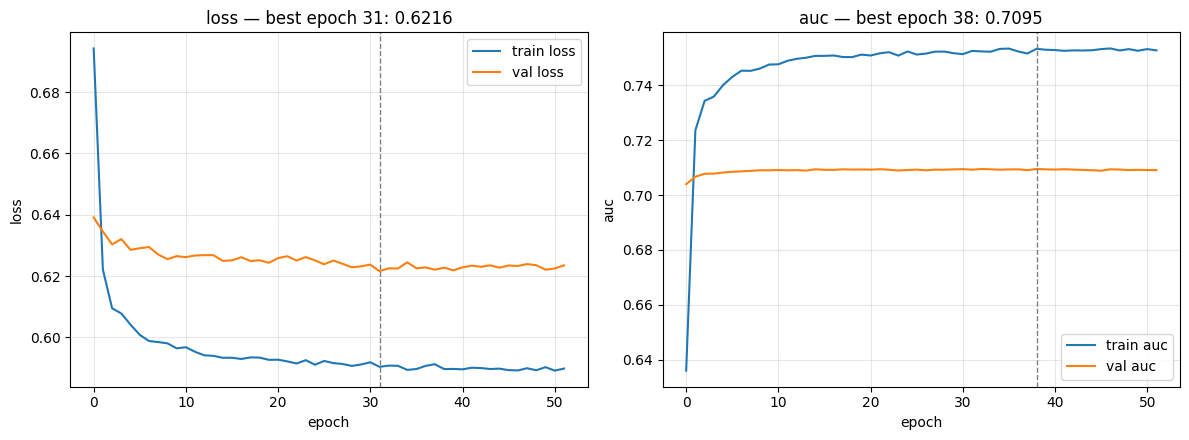

In [27]:
import matplotlib.pyplot as plt

hist = losses.history
metrics = ['loss', 'auc']

fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4.5))
axes = [axes] if len(metrics) == 1 else axes

for ax, m in zip(axes, metrics):
    ax.plot(hist[m], label=f'train {m}')
    if f'val_{m}' in hist:
        ax.plot(hist[f'val_{m}'], label=f'val {m}')

        # mark the best validation epoch (min for loss, max otherwise)
        v = hist[f'val_{m}']
        best = int(min(range(len(v)), key=lambda i: v[i])) if 'loss' in m \
            else int(max(range(len(v)), key=lambda i: v[i]))
        ax.axvline(best, ls='--', c='gray', lw=1)
        ax.set_title(f'{m} — best epoch {best}: {v[best]:.4f}')

    ax.set_xlabel('epoch')
    ax.set_ylabel(m)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score

p_test = model.predict(X_test_scaled)
print(f"test logloss: {log_loss(y_test, p_test)}")
print(f"test auc    : {roc_auc_score(y_test, p_test)}")
print(f"Test Brier  : {brier_score_loss(y_test, p_test)}")
print(f"Test Acc    : {accuracy_score(y_test, p_test > 0.5)}")

330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
test logloss: 0.6189824411525402
test auc    : 0.7126321822147326
Test Brier  : 0.21555850766795978
Test Acc    : 0.6505544498151834


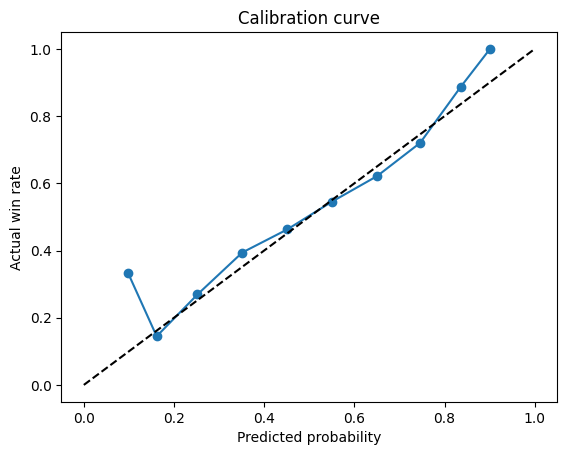

In [29]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Predicted probability'); plt.ylabel('Actual win rate')
plt.title('Calibration curve')
plt.show()

In [30]:
p_fwd = model.predict(X_val, verbose=0).ravel()
p_rev = model.predict(-X_val, verbose=0).ravel()
print(np.abs(p_fwd + p_rev - 1).max())  # should be ~1e-6

1.1920929e-07
